<a href="https://colab.research.google.com/github/KevinParker02/Colab-M.L-/blob/EDA_FundamentosML_KevinVivanco/EDA_FundamentosML_KevinVivanco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Para comenzar con el análisis del dataset importamos las librerías necesarias.

In [1]:
import numpy as np # Programación vectorial
import matplotlib.pyplot as plt # Visualización (Gráficos)
import pandas as pd # Estructura y manipulación de datos

import matplotlib.pyplot as plt # Para visualizaciones y gráficos.
import seaborn as sns # Complemento de matplotlib para realizar gráficos estadísticos.

2. Importamos el dataset desde el escritorio o donde se encuentre alojado el dataset y le asigno una variable para ser más "fácil" su uso.

In [5]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    name=fn
empleados = pd.read_csv(name, sep=",")

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv


3. Se realiza un análisis rápido de las columnas dentro del dataset, en esta ocasión las primeras 5 (Para tener la totalidad de visibilidad e las tablas utilicé el comando display.max_columns de pandas para que me muestre las 35 columnas en ves de las 20 que muetsra por defecto).

In [13]:
pd.set_option('display.max_columns', None)
empleados.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


4. Solo identifica el tipo de dato de las 35 columnas que hay presentes en el modelo.

In [21]:
categorical_cols = empleados.select_dtypes(include=['object']).columns.tolist()
numerical_cols = empleados.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columnas categóricas (object):", categorical_cols)
print("Columnas con formato numérico (int64):", numerical_cols)

Columnas con format object: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']
Columnas con formato int64: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


5. Medidas estadísticas para las columnas numéricas centradas en las que son destacadas dentro del enunciado. (Cound, moda, mediana, desviación estandar)

In [31]:
empleados[['JobSatisfaction', 'MonthlyIncome', 'YearsAtCompany', 'Education']].describe()

,JobSatisfaction,MonthlyIncome,YearsAtCompany,Education
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.728571,6502.931293,7.008163,2.912925
std,1.102846,4707.956783,6.126525,1.024165
min,1.000000,1009.000000,0.000000,1.000000
25%,2.000000,2911.000000,3.000000,2.000000
50%,3.000000,4919.000000,5.000000,3.000000
75%,4.000000,8379.000000,9.000000,4.000000
max,4.000000,19999.000000,40.000000,5.000000


6. Gráficos para análisar las variables en profundidad las variables destacadas.

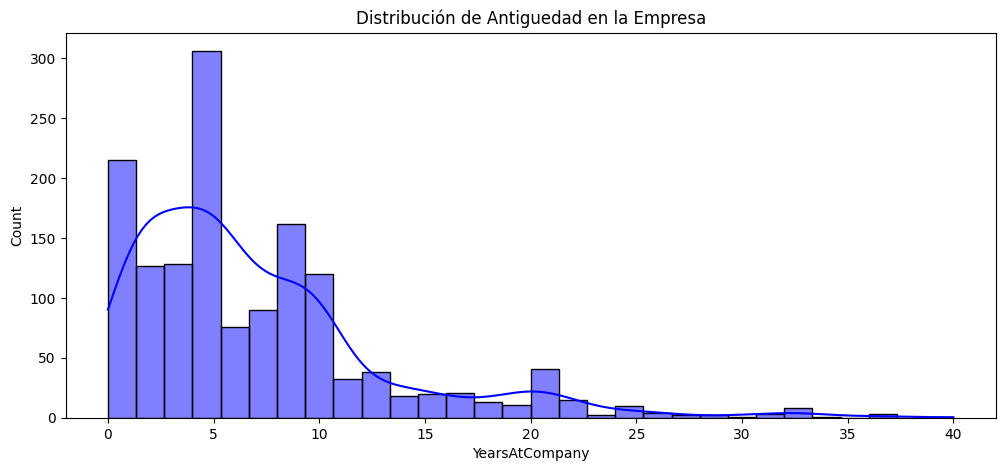

In [41]:
# Histograma hecho junto con la libreria seaborn sns que muestra la antiguedad laboral en la empresa.

plt.figure(figsize=(12, 5))
sns.histplot(empleados['YearsAtCompany'], bins=30, kde=True, color='blue')
plt.title('Distribución de Antiguedad en la Empresa')
plt.show()

lamentablemente el histográma de los años dentro de la compañía no se puede relaionar como de campana ya que no presenta una distribución normal, sino que asimétrica con una tendencia hacia la izquierda.

- Se puede decir que la moda se entra entre 0-5 años por lo que los empleados tienen poca antiguedad laboral dentro de la empresa.
- También destacar que la poca antiguedad laboral dentro de la empresa que decae drasticamente desde los 10 años en adelante.
- empleados con menos años podría indicar alta rotación en los primeros años.

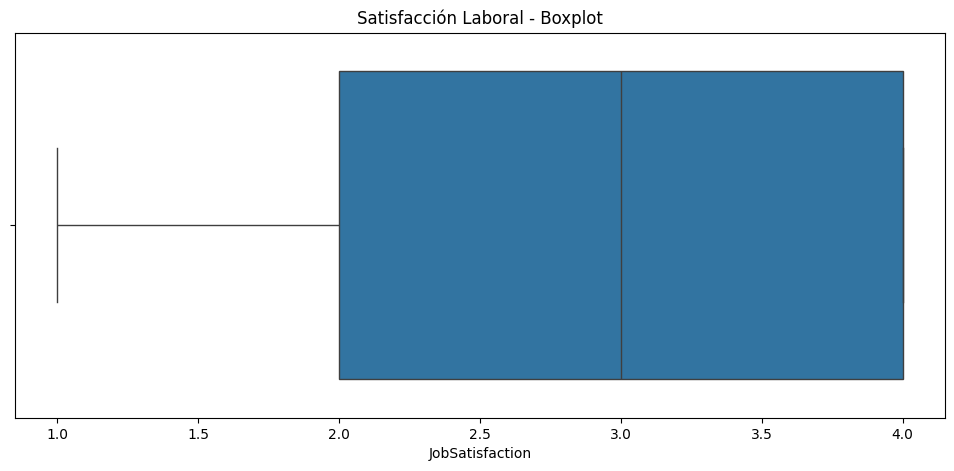

In [34]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=empleados['JobSatisfaction'])
plt.title('Satisfacción Laboral - Boxplot')
plt.show()

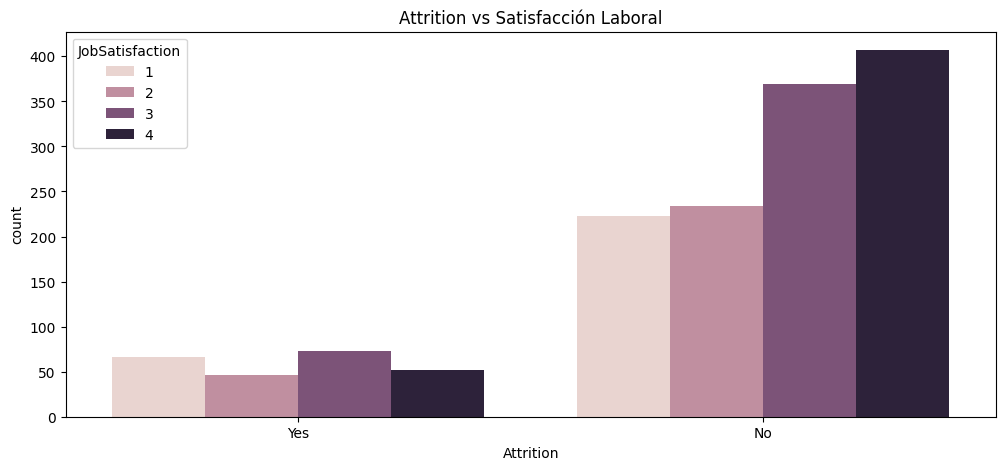

In [37]:
plt.figure(figsize=(12, 5))
sns.countplot(x='Attrition', hue='JobSatisfaction', data=empleados)
plt.title('Attrition vs Satisfacción Laboral')
plt.show()

Se uso la variable Attrition para ver la rotación de mepleados según su satisfacción laboral, por lo que se puede deducir de que empleados con alta satisfacción tienden a quedarse (No - 4) y lo que tienen baja satisfacción tienden a irse (Yes - 1).

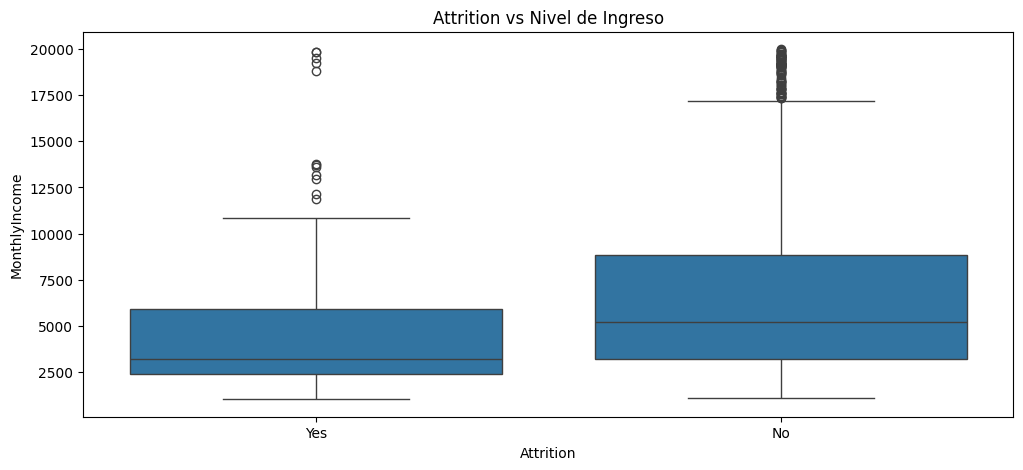

In [38]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=empleados)
plt.title('Attrition vs Nivel de Ingreso')
plt.show()


Este gráfico compara el ingreso mensual entre empleados que han dejado la empresa (Attrition = Yes) y los que permanecen (Attrition = No), se aprecia las diferencias en la mediana de ingreso entre ambos grupos y los empleados que permanecen (No) tienen una mediana salarial más alta en comparación con los que han salido (Yes). También se aprecian más valores atípicos (pelotitas a los extremos) en los empleados que permanecen, lo que indica algunos sueldos significativamente más altos.